# E-Commerce Sales Data Cleaning Using Python

## Project Overview

This project demonstrates the process of cleaning and preparing an e-commerce sales dataset using Python and Pandas.

The dataset contains common real-world data quality issues such as:

- Missing values
- Duplicate records
- Extra spaces
- Inconsistent capitalization
- Invalid quantities
- Invalid product prices
- Inconsistent date formats

The objective is to transform the raw dataset into a clean, consistent, and analysis-ready dataset.

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Google Colab

## Project Objective

The main objective is to identify and correct data quality problems while maintaining the useful information in the dataset.

The cleaned dataset will later be used for sales analysis, KPI reporting, pivot-table analysis, dashboard creation, and business insights.

# Data Cleaning Methodology

The following steps were performed during the data-cleaning process:

### 1. Initial Data Inspection
The dataset was inspected to understand its structure, number of rows, columns, data types, and sample records.

### 2. Missing Value Detection
Missing values were identified using Pandas `isna()` and their counts and percentages were calculated.

### 3. Duplicate Detection
Duplicate records were identified using the `duplicated()` function.

### 4. Duplicate Removal
Exact duplicate records were removed to avoid double-counting transactions.

### 5. Column Name Standardization
Column names were converted to lowercase and spaces were replaced with underscores for consistent Python usage.

### 6. Text Cleaning
Leading and trailing spaces were removed from text fields.

### 7. Text Standardization
Customer names, product names, categories, and regions were standardized using consistent capitalization.

### 8. Missing Customer Names
Missing customer names were replaced with the value `Unknown` rather than removing the associated transaction.

### 9. Missing Categories
Missing categories were replaced with `Uncategorized`.

### 10. Quantity Cleaning
Missing and non-positive quantities were treated as invalid and replaced using the median of valid quantities.

### 11. Price Cleaning
Missing and non-positive prices were treated as invalid. Missing prices were replaced using the median price within the corresponding category.

### 12. Date Cleaning
Order dates were converted to Pandas datetime format. Missing dates were replaced using the median valid date.

### 13. Revenue Calculation
A new Revenue column was created using:

Revenue = Quantity × Unit Price

### 14. Data Validation
Automated validation tests were performed to confirm that the cleaned dataset contained no duplicate records, invalid quantities, invalid prices, or missing required values.

### 15. Export
The cleaned dataset was exported as a CSV file for future analysis.

In [1]:
pip install pandas openpyxl numpy matplotlib seaborn

In [3]:
# ============================================
# TASK 1: DATA CLEANING IN PYTHON
# E-Commerce Sales Dataset
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
# ============================================
# CREATE RAW SAMPLE DATASET
# ============================================

data = {
    "Order_ID": [
        "ORD001", "ORD002", "ORD003", "ORD004", "ORD005",
        "ORD006", "ORD007", "ORD008", "ORD009", "ORD010",
        "ORD011", "ORD012", "ORD013", "ORD014", "ORD015",
        "ORD015", "ORD017", "ORD018", "ORD019", "ORD020"
    ],

    "Customer_Name": [
        "Rahul Sharma", " Priya Reddy ", "ARJUN KUMAR", None,
        "Sneha Rao", "Vikram Singh", "ananya reddy", "Kiran Patel",
        None, "Meena Das", "Ravi Kumar", " Priya Reddy ",
        "Amit Shah", "Neha Verma", "Rohit Mehta", "Rohit Mehta",
        "Divya Nair", "Suresh Babu", "Pooja Singh", "Anil Kumar"
    ],

    "Product": [
        "Laptop", "Wireless Mouse", "Keyboard", "Monitor", "Laptop",
        "Office Chair", "wireless mouse", "Headphones", "Keyboard",
        "Laptop", "Office Chair", "Wireless Mouse", "Monitor",
        "Headphones", "Laptop", "Laptop", "Keyboard", "Monitor",
        "Office Chair", "Headphones"
    ],

    "Category": [
        "Electronics", " Electronics ", "electronics", "Electronics",
        "Electronics", "Furniture", "Electronics", "electronics",
        None, "Electronics", " Furniture ", "electronics",
        "Electronics", "Electronics", "Electronics", "Electronics",
        " electronics ", "Electronics", "Furniture", "Electronics"
    ],

    "Quantity": [
        2, 5, 3, 1, 1,
        2, None, 4, -1, 2,
        1, 3, 2, 2, 1,
        1, 4, 2, 1, 3
    ],

    "Unit_Price": [
        55000, 1200, 1800, 15000, 55000,
        8500, 1200, 3500, 1800, None,
        8500, 1200, 15000, 3500, 55000,
        55000, 1800, 15000, 8500, -500
    ],

    "Order_Date": [
        "2026-01-05", "2026-01-06", "2026-01-07", "2026/01/08",
        "2026-01-09", "2026-01-10", "10-01-2026", "2026-01-12",
        None, "2026-01-14", "2026-01-15", "2026-01-16",
        "2026-01-17", "17/01/2026", "2026-01-19", "2026-01-19",
        "2026-01-21", "2026-01-22", "2026-01-23", "2026-01-24"
    ],

    "Region": [
        "South", "south", "South ", "North", "South",
        "West", "South", "East", "South", "North",
        "West", "south", "North", "East", "South",
        "South", "South", "North", "West", "south"
    ]
}

df = pd.DataFrame(data)

print("Raw dataset created successfully!")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Raw dataset created successfully!
Number of rows: 20
Number of columns: 8


In [5]:
# Display the raw dataset
display(df)

,Order_ID,Customer_Name,Product,Category,Quantity,Unit_Price,Order_Date,Region
0,ORD001,Rahul Sharma,Laptop,Electronics,2.0,55000.0,2026-01-05,South
1,ORD002,Priya Reddy,Wireless Mouse,Electronics,5.0,1200.0,2026-01-06,south
2,ORD003,ARJUN KUMAR,Keyboard,electronics,3.0,1800.0,2026-01-07,South
3,ORD004,None,Monitor,Electronics,1.0,15000.0,2026/01/08,North
4,ORD005,Sneha Rao,Laptop,Electronics,1.0,55000.0,2026-01-09,South
5,ORD006,Vikram Singh,Office Chair,Furniture,2.0,8500.0,2026-01-10,West
6,ORD007,ananya reddy,wireless mouse,Electronics,NaN,1200.0,10-01-2026,South
7,ORD008,Kiran Patel,Headphones,electronics,4.0,3500.0,2026-01-12,East
8,ORD009,None,Keyboard,None,-1.0,1800.0,None,South
9,ORD010,Meena Das,Laptop,Electronics,2.0,NaN,2026-01-14,North


In [6]:
# ============================================
# INITIAL DATA INSPECTION
# ============================================

print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nFirst 5 Records:")
display(df.head())

Dataset Shape:
(20, 8)

Column Names:
['Order_ID', 'Customer_Name', 'Product', 'Category', 'Quantity', 'Unit_Price', 'Order_Date', 'Region']

Data Types:
Order_ID          object
Customer_Name     object
Product           object
Category          object
Quantity         float64
Unit_Price       float64
Order_Date        object
Region            object
dtype: object

First 5 Records:


,Order_ID,Customer_Name,Product,Category,Quantity,Unit_Price,Order_Date,Region
0,ORD001,Rahul Sharma,Laptop,Electronics,2.0,55000.0,2026-01-05,South
1,ORD002,Priya Reddy,Wireless Mouse,Electronics,5.0,1200.0,2026-01-06,south
2,ORD003,ARJUN KUMAR,Keyboard,electronics,3.0,1800.0,2026-01-07,South
3,ORD004,None,Monitor,Electronics,1.0,15000.0,2026/01/08,North
4,ORD005,Sneha Rao,Laptop,Electronics,1.0,55000.0,2026-01-09,South


In [7]:
# ============================================
# CHECK MISSING VALUES
# ============================================

missing_count = df.isnull().sum()

missing_percentage = (
    df.isnull().sum() / len(df) * 100
).round(2)

missing_report = pd.DataFrame({
    "Missing_Count": missing_count,
    "Missing_Percentage": missing_percentage
})

missing_report = missing_report.sort_values(
    by="Missing_Count",
    ascending=False
)

print("Missing Value Report:")
display(missing_report)

Missing Value Report:


,Missing_Count,Missing_Percentage
Customer_Name,2,10.0
Category,1,5.0
Unit_Price,1,5.0
Quantity,1,5.0
Order_Date,1,5.0
Order_ID,0,0.0
Product,0,0.0
Region,0,0.0


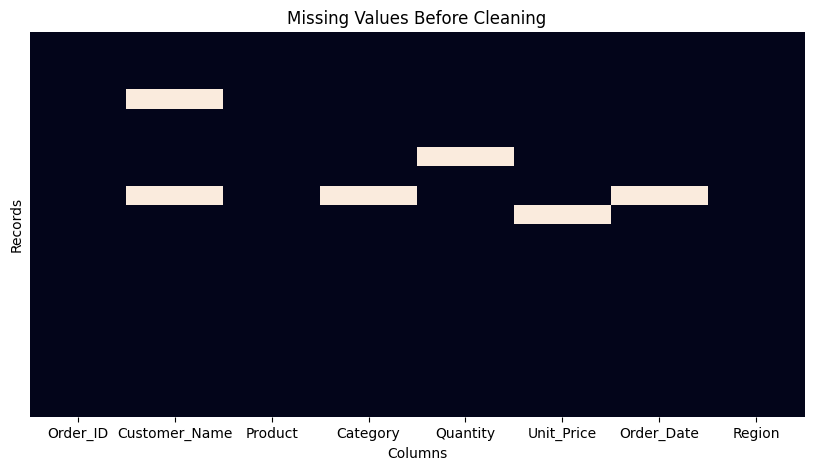

In [8]:
# ============================================
# MISSING VALUE VISUALIZATION
# ============================================

plt.figure(figsize=(10, 5))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Values Before Cleaning")
plt.xlabel("Columns")
plt.ylabel("Records")

plt.show()

In [9]:
# ============================================
# DUPLICATE CHECK
# ============================================

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

if duplicate_count > 0:
    print("\nDuplicate Records:")
    display(df[df.duplicated(keep=False)])

Number of duplicate rows: 1

Duplicate Records:


,Order_ID,Customer_Name,Product,Category,Quantity,Unit_Price,Order_Date,Region
14,ORD015,Rohit Mehta,Laptop,Electronics,1.0,55000.0,2026-01-19,South
15,ORD015,Rohit Mehta,Laptop,Electronics,1.0,55000.0,2026-01-19,South


In [10]:
# ============================================
# CREATE CLEANING COPY
# ============================================

df_clean = df.copy()

print("Cleaning copy created.")

Cleaning copy created.


In [11]:
# ============================================
# REMOVE DUPLICATES
# ============================================

rows_before_duplicates = len(df_clean)

df_clean = df_clean.drop_duplicates()

rows_after_duplicates = len(df_clean)

duplicates_removed = (
    rows_before_duplicates - rows_after_duplicates
)

print("Rows before removing duplicates:", rows_before_duplicates)
print("Rows after removing duplicates:", rows_after_duplicates)
print("Duplicates removed:", duplicates_removed)

Rows before removing duplicates: 20
Rows after removing duplicates: 19
Duplicates removed: 1


In [12]:
# ============================================
# STANDARDIZE COLUMN NAMES
# ============================================

df_clean.columns = (
    df_clean.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print("Standardized column names:")
print(df_clean.columns.tolist())

Standardized column names:
['order_id', 'customer_name', 'product', 'category', 'quantity', 'unit_price', 'order_date', 'region']


In [13]:
# ============================================
# TEXT STANDARDIZATION
# ============================================

text_columns = [
    "customer_name",
    "product",
    "category",
    "region"
]

for column in text_columns:
    df_clean[column] = (
        df_clean[column]
        .astype("string")
        .str.strip()
    )

print("Extra spaces removed from text columns.")

Extra spaces removed from text columns.


In [14]:
# ============================================
# STANDARDIZE TEXT CASE
# ============================================

df_clean["customer_name"] = (
    df_clean["customer_name"]
    .str.title()
)

df_clean["product"] = (
    df_clean["product"]
    .str.title()
)

df_clean["category"] = (
    df_clean["category"]
    .str.title()
)

df_clean["region"] = (
    df_clean["region"]
    .str.title()
)

print("Text capitalization standardized.")

Text capitalization standardized.


In [15]:
# ============================================
# HANDLE MISSING CUSTOMER NAMES
# ============================================

missing_customers_before = df_clean["customer_name"].isna().sum()

df_clean["customer_name"] = (
    df_clean["customer_name"]
    .fillna("Unknown")
)

missing_customers_after = df_clean["customer_name"].isna().sum()

print("Missing customer names before:", missing_customers_before)
print("Missing customer names after:", missing_customers_after)

Missing customer names before: 2
Missing customer names after: 0


In [16]:
# ============================================
# HANDLE MISSING CATEGORIES
# ============================================

missing_categories_before = df_clean["category"].isna().sum()

df_clean["category"] = (
    df_clean["category"]
    .fillna("Uncategorized")
)

missing_categories_after = df_clean["category"].isna().sum()

print("Missing categories before:", missing_categories_before)
print("Missing categories after:", missing_categories_after)

Missing categories before: 1
Missing categories after: 0


In [17]:
# ============================================
# CONVERT NUMERIC COLUMNS
# ============================================

df_clean["quantity"] = pd.to_numeric(
    df_clean["quantity"],
    errors="coerce"
)

df_clean["unit_price"] = pd.to_numeric(
    df_clean["unit_price"],
    errors="coerce"
)

print(df_clean[["quantity", "unit_price"]].dtypes)

quantity      float64
unit_price    float64
dtype: object


In [18]:
# ============================================
# HANDLE INVALID QUANTITY VALUES
# ============================================

valid_quantity_median = df_clean.loc[
    df_clean["quantity"] > 0,
    "quantity"
].median()

invalid_quantity_count = (
    (df_clean["quantity"] <= 0).sum()
)

missing_quantity_count = (
    df_clean["quantity"].isna().sum()
)

print("Valid quantity median:", valid_quantity_median)
print("Invalid quantity values:", invalid_quantity_count)
print("Missing quantity values:", missing_quantity_count)

# Replace invalid quantities with NaN
df_clean.loc[
    df_clean["quantity"] <= 0,
    "quantity"
] = np.nan

# Fill missing/invalid quantities with median
df_clean["quantity"] = (
    df_clean["quantity"]
    .fillna(valid_quantity_median)
)

print("\nQuantity cleaning completed.")

Valid quantity median: 2.0
Invalid quantity values: 1
Missing quantity values: 1

Quantity cleaning completed.


In [19]:
# ============================================
# HANDLE INVALID/MISSING PRICES
# ============================================

# Treat zero/negative prices as missing
df_clean.loc[
    df_clean["unit_price"] <= 0,
    "unit_price"
] = np.nan

# Calculate category-level median price
category_price_median = (
    df_clean
    .groupby("category")["unit_price"]
    .transform("median")
)

# Fill missing prices using category median
df_clean["unit_price"] = (
    df_clean["unit_price"]
    .fillna(category_price_median)
)

# If any price is still missing, use overall median
df_clean["unit_price"] = (
    df_clean["unit_price"]
    .fillna(df_clean["unit_price"].median())
)

print("Price cleaning completed.")

Price cleaning completed.


In [20]:
# ============================================
# DATE STANDARDIZATION
# ============================================

df_clean["order_date"] = pd.to_datetime(
    df_clean["order_date"],
    errors="coerce",
    dayfirst=False
)

print("Date conversion completed.")
print(df_clean["order_date"].head())

Date conversion completed.
0   2026-01-05
1   2026-01-06
2   2026-01-07
3          NaT
4   2026-01-09
Name: order_date, dtype: datetime64[ns]


In [21]:
# ============================================
# HANDLE MISSING DATES
# ============================================

missing_dates_before = df_clean["order_date"].isna().sum()

# Use the median valid date
median_date = df_clean["order_date"].dropna().sort_values().iloc[
    len(df_clean["order_date"].dropna()) // 2
]

df_clean["order_date"] = (
    df_clean["order_date"]
    .fillna(median_date)
)

missing_dates_after = df_clean["order_date"].isna().sum()

print("Missing dates before:", missing_dates_before)
print("Missing dates after:", missing_dates_after)
print("Replacement date:", median_date)

Missing dates before: 4
Missing dates after: 0
Replacement date: 2026-01-15 00:00:00


In [22]:
# ============================================
# STANDARDIZE DATE FORMAT
# ============================================

df_clean["order_date"] = pd.to_datetime(
    df_clean["order_date"]
)

print(df_clean["order_date"].dt.strftime("%Y-%m-%d").head())

0    2026-01-05
1    2026-01-06
2    2026-01-07
3    2026-01-15
4    2026-01-09
Name: order_date, dtype: object


In [23]:
# ============================================
# CREATE REVENUE COLUMN
# ============================================

df_clean["revenue"] = (
    df_clean["quantity"] *
    df_clean["unit_price"]
)

print("Revenue column created.")
display(
    df_clean[
        [
            "order_id",
            "product",
            "quantity",
            "unit_price",
            "revenue"
        ]
    ].head(10)
)

Revenue column created.


,order_id,product,quantity,unit_price,revenue
0,ORD001,Laptop,2.0,55000.0,110000.0
1,ORD002,Wireless Mouse,5.0,1200.0,6000.0
2,ORD003,Keyboard,3.0,1800.0,5400.0
3,ORD004,Monitor,1.0,15000.0,15000.0
4,ORD005,Laptop,1.0,55000.0,55000.0
5,ORD006,Office Chair,2.0,8500.0,17000.0
6,ORD007,Wireless Mouse,2.0,1200.0,2400.0
7,ORD008,Headphones,4.0,3500.0,14000.0
8,ORD009,Keyboard,2.0,1800.0,3600.0
9,ORD010,Laptop,2.0,3500.0,7000.0


In [24]:
# ============================================
# FINAL DATA QUALITY CHECKS
# ============================================

print("=" * 50)
print("FINAL DATA QUALITY CHECK")
print("=" * 50)

print(
    "Duplicate rows:",
    df_clean.duplicated().sum()
)

print(
    "Missing customer names:",
    df_clean["customer_name"].isna().sum()
)

print(
    "Missing categories:",
    df_clean["category"].isna().sum()
)

print(
    "Missing quantities:",
    df_clean["quantity"].isna().sum()
)

print(
    "Invalid quantities:",
    (df_clean["quantity"] <= 0).sum()
)

print(
    "Missing prices:",
    df_clean["unit_price"].isna().sum()
)

print(
    "Invalid prices:",
    (df_clean["unit_price"] <= 0).sum()
)

print(
    "Missing dates:",
    df_clean["order_date"].isna().sum()
)

FINAL DATA QUALITY CHECK
Duplicate rows: 0
Missing customer names: 0
Missing categories: 0
Missing quantities: 0
Invalid quantities: 0
Missing prices: 0
Invalid prices: 0
Missing dates: 0


In [25]:
# ============================================
# AUTOMATED VALIDATION TESTS
# ============================================

assert df_clean.duplicated().sum() == 0

assert df_clean["customer_name"].isna().sum() == 0

assert df_clean["category"].isna().sum() == 0

assert df_clean["quantity"].isna().sum() == 0

assert (df_clean["quantity"] > 0).all()

assert df_clean["unit_price"].isna().sum() == 0

assert (df_clean["unit_price"] > 0).all()

assert df_clean["order_date"].isna().sum() == 0

assert df_clean["revenue"].isna().sum() == 0

print("✅ ALL DATA QUALITY TESTS PASSED!")

✅ ALL DATA QUALITY TESTS PASSED!


In [29]:
print("Current df columns:")
print(df.columns.tolist())

print("\nCurrent df_clean columns:")
print(df_clean.columns.tolist())

Current df columns:
['Order_ID', 'Customer_Name', 'Product', 'Category', 'Quantity', 'Unit_Price', 'Order_Date', 'Region']

Current df_clean columns:
['order_id', 'customer_name', 'product', 'category', 'quantity', 'unit_price', 'order_date', 'region', 'revenue']


In [30]:
# ============================================
# BEFORE vs AFTER CLEANING SUMMARY
# ============================================

# Make sure column names are standardized
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

df_clean.columns = (
    df_clean.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

# Create BEFORE values
before_duplicate = df.duplicated().sum()

before_missing_customer = df["customer_name"].isna().sum()

before_missing_category = df["category"].isna().sum()

before_missing_quantity = df["quantity"].isna().sum()

before_invalid_quantity = (
    pd.to_numeric(
        df["quantity"],
        errors="coerce"
    ) <= 0
).sum()

before_missing_price = df["unit_price"].isna().sum()

before_invalid_price = (
    pd.to_numeric(
        df["unit_price"],
        errors="coerce"
    ) <= 0
).sum()

before_missing_date = pd.to_datetime(
    df["order_date"],
    errors="coerce"
).isna().sum()


# Create AFTER values
after_duplicate = df_clean.duplicated().sum()

after_missing_customer = df_clean["customer_name"].isna().sum()

after_missing_category = df_clean["category"].isna().sum()

after_missing_quantity = df_clean["quantity"].isna().sum()

after_invalid_quantity = (
    df_clean["quantity"] <= 0
).sum()

after_missing_price = df_clean["unit_price"].isna().sum()

after_invalid_price = (
    df_clean["unit_price"] <= 0
).sum()

after_missing_date = df_clean["order_date"].isna().sum()


# Create summary table
summary = pd.DataFrame({

    "Metric": [
        "Total Rows",
        "Total Columns",
        "Duplicate Rows",
        "Missing Customer Names",
        "Missing Categories",
        "Missing Quantity",
        "Invalid Quantity",
        "Missing Unit Price",
        "Invalid Unit Price",
        "Missing Order Dates"
    ],

    "Before Cleaning": [
        len(df),
        len(df.columns),
        before_duplicate,
        before_missing_customer,
        before_missing_category,
        before_missing_quantity,
        before_invalid_quantity,
        before_missing_price,
        before_invalid_price,
        before_missing_date
    ],

    "After Cleaning": [
        len(df_clean),
        len(df_clean.columns),
        after_duplicate,
        after_missing_customer,
        after_missing_category,
        after_missing_quantity,
        after_invalid_quantity,
        after_missing_price,
        after_invalid_price,
        after_missing_date
    ]
})

display(summary)


,Metric,Before Cleaning,After Cleaning
0,Total Rows,20,19
1,Total Columns,8,9
2,Duplicate Rows,1,0
3,Missing Customer Names,2,0
4,Missing Categories,1,0
5,Missing Quantity,1,0
6,Invalid Quantity,1,0
7,Missing Unit Price,1,0
8,Invalid Unit Price,1,0
9,Missing Order Dates,4,0


In [31]:
# ============================================
# DATA CLEANING IMPACT REPORT
# ============================================

# Standardize column names
for dataset in [df, df_clean]:
    dataset.columns = (
        dataset.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
    )


# Calculate metrics
before_metrics = {
    "Total Rows": len(df),
    "Total Columns": len(df.columns),
    "Duplicate Rows": df.duplicated().sum(),
    "Missing Customer Names": df["customer_name"].isna().sum(),
    "Missing Categories": df["category"].isna().sum(),
    "Missing Quantity": df["quantity"].isna().sum(),
    "Invalid Quantity": (pd.to_numeric(
        df["quantity"], errors="coerce"
    ) <= 0).sum(),
    "Missing Unit Price": df["unit_price"].isna().sum(),
    "Invalid Unit Price": (pd.to_numeric(
        df["unit_price"], errors="coerce"
    ) <= 0).sum(),
    "Missing Order Dates": pd.to_datetime(
        df["order_date"], errors="coerce"
    ).isna().sum()
}


after_metrics = {
    "Total Rows": len(df_clean),
    "Total Columns": len(df_clean.columns),
    "Duplicate Rows": df_clean.duplicated().sum(),
    "Missing Customer Names": df_clean["customer_name"].isna().sum(),
    "Missing Categories": df_clean["category"].isna().sum(),
    "Missing Quantity": df_clean["quantity"].isna().sum(),
    "Invalid Quantity": (df_clean["quantity"] <= 0).sum(),
    "Missing Unit Price": df_clean["unit_price"].isna().sum(),
    "Invalid Unit Price": (df_clean["unit_price"] <= 0).sum(),
    "Missing Order Dates": df_clean["order_date"].isna().sum()
}


# Build report
summary = pd.DataFrame({
    "Metric": list(before_metrics.keys()),
    "Before Cleaning": list(before_metrics.values()),
    "After Cleaning": list(after_metrics.values())
})


# Add improvement column
summary["Improvement"] = (
    summary["Before Cleaning"] -
    summary["After Cleaning"]
)


print("=" * 70)
print("DATA CLEANING IMPACT REPORT")
print("=" * 70)

display(summary)

DATA CLEANING IMPACT REPORT


,Metric,Before Cleaning,After Cleaning,Improvement
0,Total Rows,20,19,1
1,Total Columns,8,9,-1
2,Duplicate Rows,1,0,1
3,Missing Customer Names,2,0,2
4,Missing Categories,1,0,1
5,Missing Quantity,1,0,1
6,Invalid Quantity,1,0,1
7,Missing Unit Price,1,0,1
8,Invalid Unit Price,1,0,1
9,Missing Order Dates,4,0,4


In [32]:
# ============================================
# FINAL CLEANED DATASET
# ============================================

print("FINAL CLEANED DATASET")
print("=" * 50)

print("Rows:", df_clean.shape[0])
print("Columns:", df_clean.shape[1])

display(df_clean)

FINAL CLEANED DATASET
Rows: 19
Columns: 9


,order_id,customer_name,product,category,quantity,unit_price,order_date,region,revenue
0,ORD001,Rahul Sharma,Laptop,Electronics,2.0,55000.0,2026-01-05,South,110000.0
1,ORD002,Priya Reddy,Wireless Mouse,Electronics,5.0,1200.0,2026-01-06,South,6000.0
2,ORD003,Arjun Kumar,Keyboard,Electronics,3.0,1800.0,2026-01-07,South,5400.0
3,ORD004,Unknown,Monitor,Electronics,1.0,15000.0,2026-01-15,North,15000.0
4,ORD005,Sneha Rao,Laptop,Electronics,1.0,55000.0,2026-01-09,South,55000.0
5,ORD006,Vikram Singh,Office Chair,Furniture,2.0,8500.0,2026-01-10,West,17000.0
6,ORD007,Ananya Reddy,Wireless Mouse,Electronics,2.0,1200.0,2026-01-15,South,2400.0
7,ORD008,Kiran Patel,Headphones,Electronics,4.0,3500.0,2026-01-12,East,14000.0
8,ORD009,Unknown,Keyboard,Uncategorized,2.0,1800.0,2026-01-15,South,3600.0
9,ORD010,Meena Das,Laptop,Electronics,2.0,3500.0,2026-01-14,North,7000.0


In [33]:
# ============================================
# EXPORT CLEANED DATASET
# ============================================

output_file = "cleaned_ecommerce_sales.csv"

df_clean.to_csv(
    output_file,
    index=False
)

print(f"✅ Cleaned dataset saved as: {output_file}")

✅ Cleaned dataset saved as: cleaned_ecommerce_sales.csv


In [34]:
# ============================================
# DOWNLOAD CLEANED DATASET
# ============================================

from google.colab import files

files.download("cleaned_ecommerce_sales.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

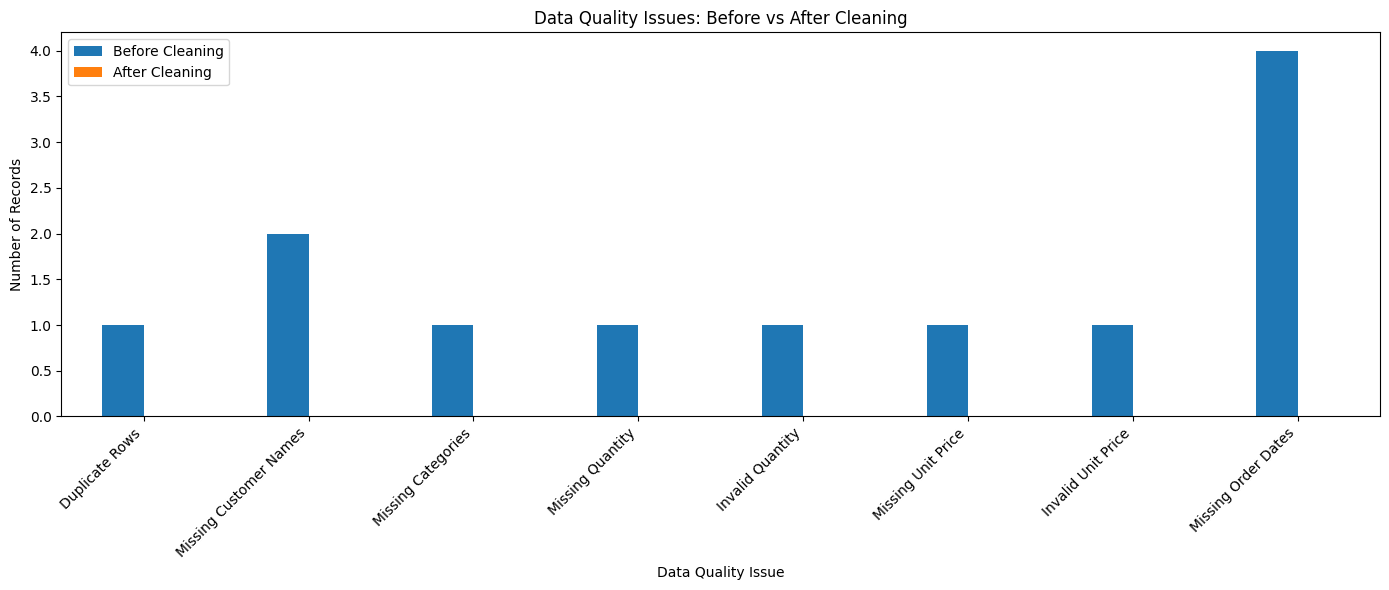

In [39]:
# ============================================
# BEFORE VS AFTER DATA QUALITY VISUALIZATION
# ============================================

quality_metrics = [
    "Duplicate Rows",
    "Missing Customer Names",
    "Missing Categories",
    "Missing Quantity",
    "Invalid Quantity",
    "Missing Unit Price",
    "Invalid Unit Price",
    "Missing Order Dates"
]

before_values = [
    before_duplicate,
    before_missing_customer,
    before_missing_category,
    before_missing_quantity,
    before_invalid_quantity,
    before_missing_price,
    before_invalid_price,
    before_missing_date
]

after_values = [
    after_duplicate,
    after_missing_customer,
    after_missing_category,
    after_missing_quantity,
    after_invalid_quantity,
    after_missing_price,
    after_invalid_price,
    after_missing_date
]

comparison = pd.DataFrame({
    "Before Cleaning": before_values,
    "After Cleaning": after_values
}, index=quality_metrics)

comparison.plot(
    kind="bar",
    figsize=(14, 6)
)

plt.title("Data Quality Issues: Before vs After Cleaning")
plt.ylabel("Number of Records")
plt.xlabel("Data Quality Issue")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [40]:
# ============================================
# FINAL CLEANED DATASET PREVIEW
# ============================================

print("Final Dataset Shape:", df_clean.shape)

display(
    df_clean.head(10)
)

Final Dataset Shape: (19, 9)


,order_id,customer_name,product,category,quantity,unit_price,order_date,region,revenue
0,ORD001,Rahul Sharma,Laptop,Electronics,2.0,55000.0,2026-01-05,South,110000.0
1,ORD002,Priya Reddy,Wireless Mouse,Electronics,5.0,1200.0,2026-01-06,South,6000.0
2,ORD003,Arjun Kumar,Keyboard,Electronics,3.0,1800.0,2026-01-07,South,5400.0
3,ORD004,Unknown,Monitor,Electronics,1.0,15000.0,2026-01-15,North,15000.0
4,ORD005,Sneha Rao,Laptop,Electronics,1.0,55000.0,2026-01-09,South,55000.0
5,ORD006,Vikram Singh,Office Chair,Furniture,2.0,8500.0,2026-01-10,West,17000.0
6,ORD007,Ananya Reddy,Wireless Mouse,Electronics,2.0,1200.0,2026-01-15,South,2400.0
7,ORD008,Kiran Patel,Headphones,Electronics,4.0,3500.0,2026-01-12,East,14000.0
8,ORD009,Unknown,Keyboard,Uncategorized,2.0,1800.0,2026-01-15,South,3600.0
9,ORD010,Meena Das,Laptop,Electronics,2.0,3500.0,2026-01-14,North,7000.0


In [41]:
# Show final data types

print("Final Data Types:")
display(
    df_clean.dtypes.to_frame("Data Type")
)

Final Data Types:


,Data Type
order_id,object
customer_name,string[python]
product,string[python]
category,string[python]
quantity,float64
unit_price,float64
order_date,datetime64[ns]
region,string[python]
revenue,float64


In [42]:
# Final missing-value check

print("Final Missing Value Check:")

final_missing = df_clean.isna().sum()

display(
    final_missing.to_frame("Missing Values")
)

Final Missing Value Check:


,Missing Values
order_id,0
customer_name,0
product,0
category,0
quantity,0
unit_price,0
order_date,0
region,0
revenue,0


# Final Validation

After the cleaning process, the dataset was validated using automated checks.

The validation confirmed that:

- Duplicate records were removed.
- Customer names no longer contain missing values.
- Categories no longer contain missing values.
- Quantities are positive.
- Unit prices are positive.
- Order dates are valid.
- Revenue values are available.
- The cleaned dataset is ready for further analysis.

The final dataset was exported as `cleaned_ecommerce_sales.csv`.